In [24]:
# including libraries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
dataset=pd.read_csv("Salary.csv")

In [4]:
dataset.head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0


In [7]:
# Checking Null values in Table

dataset.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [6]:
# Dropping Null Values

dataset.dropna(inplace=True)

<Figure size 300x300 with 0 Axes>

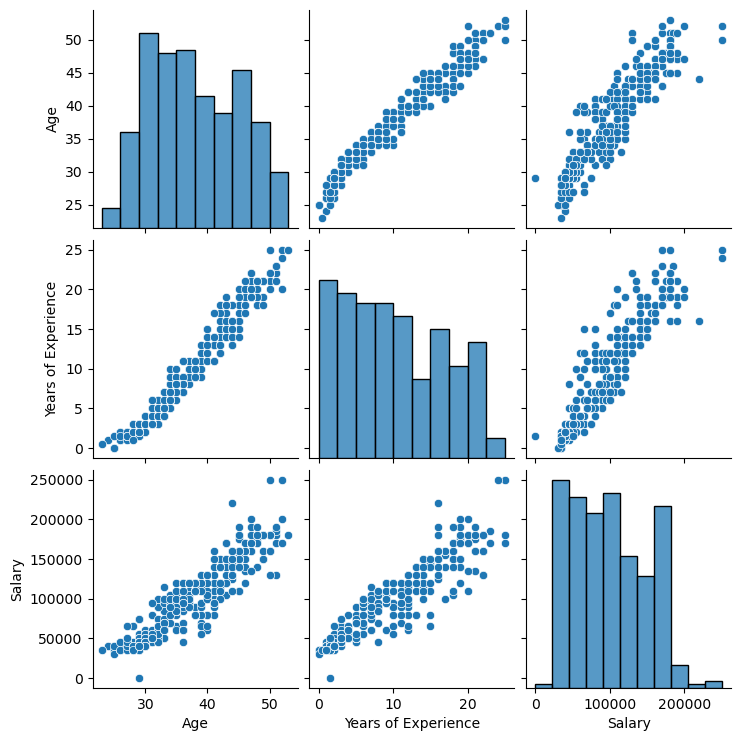

In [11]:
# Checking linearity in Columns

plt.figure(figsize=(3,3))
sns.pairplot(data=dataset)
plt.show()

In [12]:
# Checking Outliers but not present

dataset.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [23]:
dataset.head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1.0,0.0,159,5.0,90000.0
1,28.0,0.0,1.0,17,3.0,65000.0
2,45.0,1.0,2.0,130,15.0,150000.0


In [17]:
# Encoding on Gender

oe=OneHotEncoder(drop="first")

dataset["Gender"]=oe.fit_transform(dataset[["Gender"]]).toarray()

In [19]:
# Encoding On Job Title

le=LabelEncoder()

dataset["Job Title"]=le.fit_transform(dataset[["Job Title"]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [22]:
# Encoding On Eduction Level

dataset["Education Level"].unique()

cate=[["Bachelor's", "Master's", 'PhD']]

ohe=OrdinalEncoder(categories=cate)

dataset["Education Level"]=ohe.fit_transform(dataset[["Education Level"]])

In [27]:

# Standard Scaler

ss=StandardScaler()

new_data=ss.fit_transform(dataset)

dataset=pd.DataFrame(new_data,columns=dataset.columns)

In [30]:
# Checking Data

dataset.head(3)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,-0.769398,0.960563,-0.742035,1.486480,-0.768276,-0.219559
1,-1.336003,-1.041057,0.641860,-1.570634,-1.073702,-0.738498
2,1.072068,0.960563,2.025754,0.862140,0.758859,1.025892


In [31]:
# Train test split

x=dataset.iloc[:,:-1]

y=dataset["Salary"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
# Final Version

model=LinearRegression()

model.fit(x_test,y_test)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
# Checking Score

model.score(x_test,y_test)*100

92.370430713993

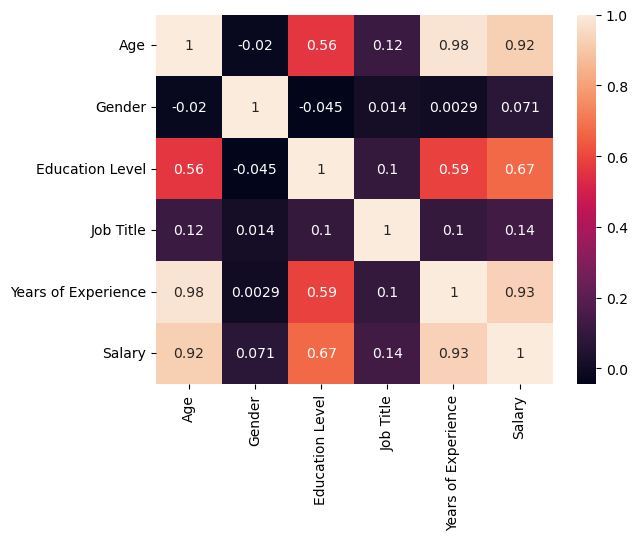

In [37]:
sns.heatmap(data=dataset.corr(),annot=True)
plt.show()